In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import pandas as pd

import random

In [2]:
# Define the models
class SignalClassifier(nn.Module):
    def __init__(self, input_channels, filter_size, win_len):
        super(SignalClassifier, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=2, kernel_size=filter_size, padding='same')
        self.bn1 = nn.BatchNorm1d(2)
        self.prelu1 = nn.PReLU()

        self.branch1_layers = nn.ModuleList()
        self.branch1_bns = nn.ModuleList()
        for i in range(2):
            self.branch1_layers.append(nn.Conv1d(in_channels=2 if i == 0 else 8, out_channels=8, kernel_size=filter_size, padding='same'))
            self.branch1_bns.append(nn.BatchNorm1d(8))
        self.branch1_prelus = nn.ModuleList([nn.PReLU() for _ in range(2)])
        self.out_branch1 = nn.Conv1d(in_channels=8, out_channels=8, kernel_size=filter_size, padding='same')
        
        self.fc1_branch1 = nn.Linear(8*win_len, 128)
        self.fc2_branch1 = nn.Linear(128, 1)

        self.branch2_layers = nn.ModuleList()
        self.branch2_bns = nn.ModuleList()
        for i in range(2):
            self.branch2_layers.append(nn.Conv1d(in_channels=2 if i == 0 else 8, out_channels=8, kernel_size=filter_size, padding='same'))
            self.branch2_bns.append(nn.BatchNorm1d(8))
        self.branch2_prelus = nn.ModuleList([nn.PReLU() for _ in range(2)])
        self.out_branch2 = nn.Conv1d(in_channels=8, out_channels=8, kernel_size=filter_size, padding='same')
        
        self.fc1_branch2 = nn.Linear(8*win_len, 128)
        self.fc2_branch2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.prelu1(self.bn1(self.conv1(x)))

        x_branch1 = x
        for layer, bn, prelu in zip(self.branch1_layers, self.branch1_bns, self.branch1_prelus):
            x_branch1 = prelu(bn(layer(x_branch1)))
        x_branch1_f = self.out_branch1(x_branch1)
        x_branch1 = x_branch1.view(x_branch1_f.size(0), -1)
        x_branch1 = F.relu(self.fc1_branch1(x_branch1))
        out1 = self.fc2_branch1(x_branch1)

        x_branch2 = x
        for layer, bn, prelu in zip(self.branch2_layers, self.branch2_bns, self.branch2_prelus):
            x_branch2 = prelu(bn(layer(x_branch2)))
        x_branch2_f = self.out_branch2(x_branch2)
        x_branch2 = x_branch2.view(x_branch2_f.size(0), -1)
        x_branch2 = F.relu(self.fc1_branch2(x_branch2))
        out2 = self.fc2_branch2(x_branch2)

        return out1, out2, x_branch1_f, x_branch2_f

# Define dataset class
class CustomDataset(Dataset):
    def __init__(self, data, modes, names):
        self.data = data
        self.modes = modes
        self.names = names

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        mode = self.modes[idx]
        name = self.names[idx]
        return sample, mode, name


In [3]:
# Define helper functions for evaluation and plotting
def plot_raw_signal(signal, sampling_rate, title):
    time = np.arange(signal.shape[-1]) / sampling_rate * 1000  # Convert to ms
    signal = signal.cpu().numpy().flatten()
    plt.figure(figsize=(10, 5))
    plt.plot(time, signal)
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.show()

def plot_combined_channels(x_branch1, x_branch2, sampling_rate, title):
    fig, axes = plt.subplots(4, 2, figsize=(15, 20), sharex=True)
    axes = axes.flatten()
    time = np.arange(x_branch1.shape[-1]) / sampling_rate * 1000  # Convert to ms
    for i in range(8):
        axes[i].plot(time, x_branch1[i], label=f'Branch 1 - Channel {i+1}', color='b')
        axes[i].plot(time, x_branch2[i], label=f'Branch 2 - Channel {i+1}', color='r')
        axes[i].set_title(f'Channel {i+1}')
        axes[i].set_xlabel('Time (ms)')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_combined_spectrum(x_branch1, x_branch2, sampling_rate, title, max_freq=None):
    fig, axes = plt.subplots(4, 2, figsize=(15, 20), sharex=True)
    axes = axes.flatten()
    for i in range(8):
        signal1 = x_branch1[i].numpy().flatten()
        signal2 = x_branch2[i].numpy().flatten()
        n = len(signal1)
        fhat1 = np.fft.fft(signal1, n)
        fhat2 = np.fft.fft(signal2, n)
        psd1 = np.abs(fhat1) ** 2
        psd2 = np.abs(fhat2) ** 2
        freq = np.fft.fftfreq(n, 1 / sampling_rate)
        
        l = np.arange(1, np.floor(n / 2), dtype=int)  # Only plot the positive frequencies

        if max_freq is not None:
            l = l[freq[l] <= max_freq]  # Limit the frequencies to max_freq

        axes[i].plot(freq[l], psd1[l], label=f'Branch 1 - Channel {i+1}', color='b')
        axes[i].plot(freq[l], psd2[l], label=f'Branch 2 - Channel {i+1}', color='r')
        axes[i].set_title(f'Channel {i+1}')
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Power Spectral Density')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [4]:
# Load data and filter only the rear sensor
test_database_sim = torch.load('./Data/test_classification_short_TEST')
test_names_sim = test_database_sim['file_names']
test_modes_sim = test_database_sim['mode_descriptions']

def mode_to_int(mode):
    return 0 if 'Conduction' in mode else 1

test_modes_int_sim = [(mode_to_int(mode0), mode_to_int(mode1)) for mode0, mode1 in test_modes_sim]
test_data_sim = test_database_sim['sim_tensor']
test_data_sim_a = test_data_sim.narrow(1, 1, 1)  # Only rear

# Set random seed
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Create DataLoader
test_dataset_sim = CustomDataset(test_data_sim_a, test_modes_int_sim, test_names_sim)
test_loader_sim = DataLoader(test_dataset_sim, batch_size=64, shuffle=True)

# Load model
model_sim_path = './best_model_only_rear.pth'
model_sim_data = torch.load(model_sim_path, map_location=torch.device('cpu'))
win_len = test_data_sim_a.shape[2]
best_filter_size_sim = model_sim_data['conv1.weight'].shape[-1]

device = torch.device("cpu")
model_sim = SignalClassifier(input_channels=test_data_sim_a.shape[1], filter_size=best_filter_size_sim, win_len=win_len).to(device)
model_sim.load_state_dict(model_sim_data)
model_sim.eval()



SignalClassifier(
  (conv1): Conv1d(1, 2, kernel_size=(101,), stride=(1,), padding=same)
  (bn1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (prelu1): PReLU(num_parameters=1)
  (branch1_layers): ModuleList(
    (0): Conv1d(2, 8, kernel_size=(101,), stride=(1,), padding=same)
    (1): Conv1d(8, 8, kernel_size=(101,), stride=(1,), padding=same)
  )
  (branch1_bns): ModuleList(
    (0-1): 2 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch1_prelus): ModuleList(
    (0-1): 2 x PReLU(num_parameters=1)
  )
  (out_branch1): Conv1d(8, 8, kernel_size=(101,), stride=(1,), padding=same)
  (fc1_branch1): Linear(in_features=40000, out_features=128, bias=True)
  (fc2_branch1): Linear(in_features=128, out_features=1, bias=True)
  (branch2_layers): ModuleList(
    (0): Conv1d(2, 8, kernel_size=(101,), stride=(1,), padding=same)
    (1): Conv1d(8, 8, kernel_size=(101,), stride=(1,), padding=same)
  )
  (branch2_bns): Mod

This supplementary material provides a detailed evaluation of our model and a comprehensive analysis of the detected signals. The focus is on verifying the signals in four different scenarios: both locations in conduction mode, both locations in keyhole mode, one location in keyhole mode and the other in conduction mode.

We utilize the trained model to evaluate and plot the signals from the test dataset. Specifically, we aim to:

1. Select representative signals from each of the four scenarios.
2. Plot the raw signals for each scenario.
3. Plot the filtered signals from both branches of the model.
4. Analyze the spectrum of the filtered signals to understand the frequency characteristics.



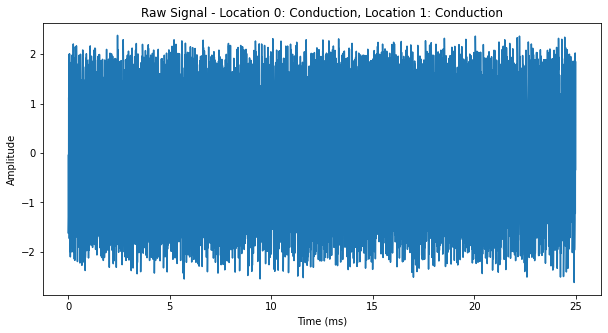

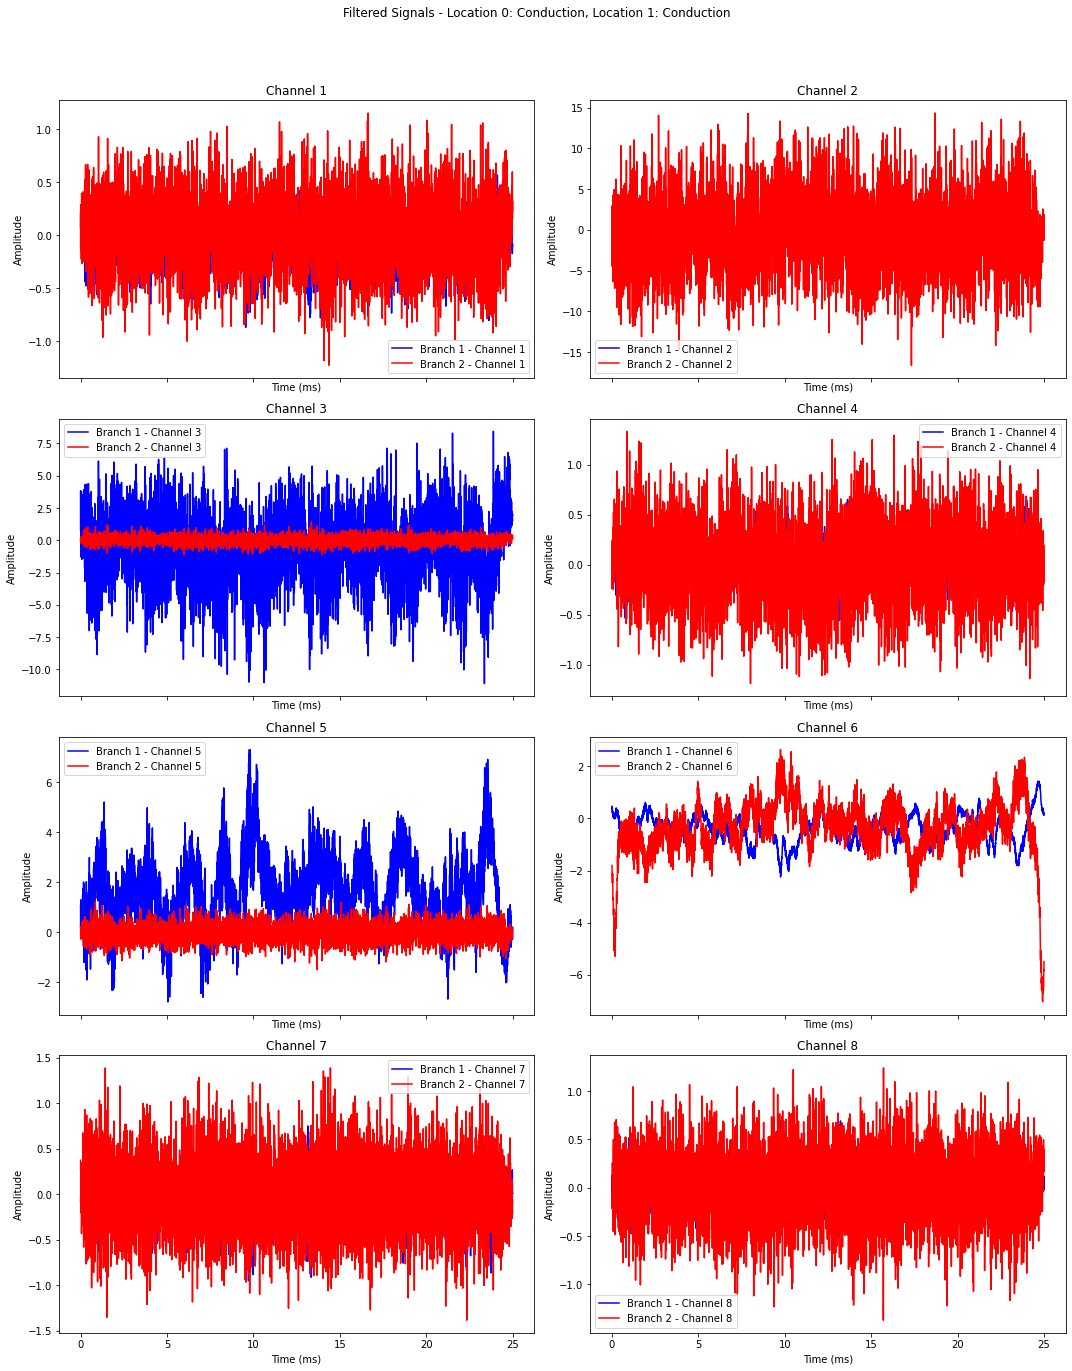

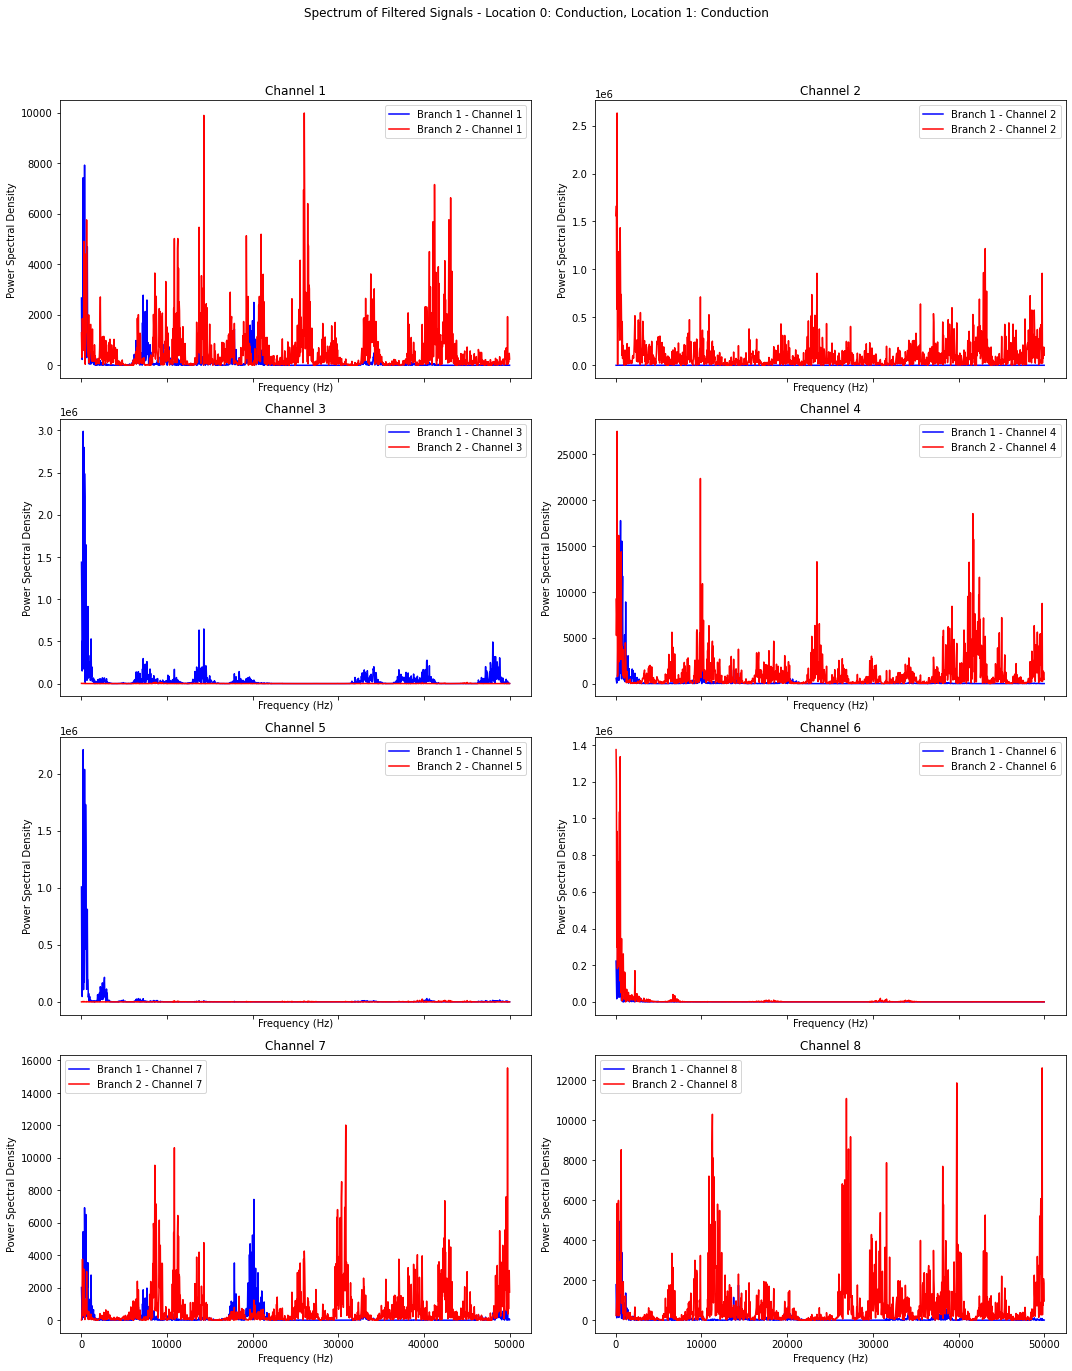

----------------------------------------


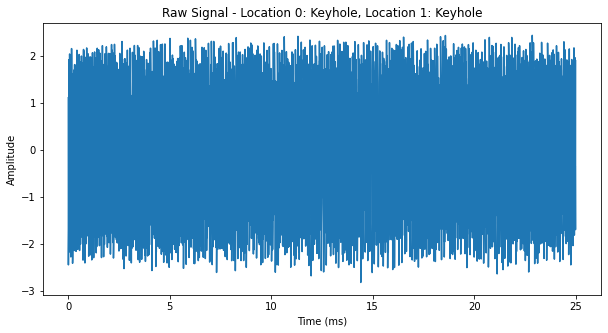

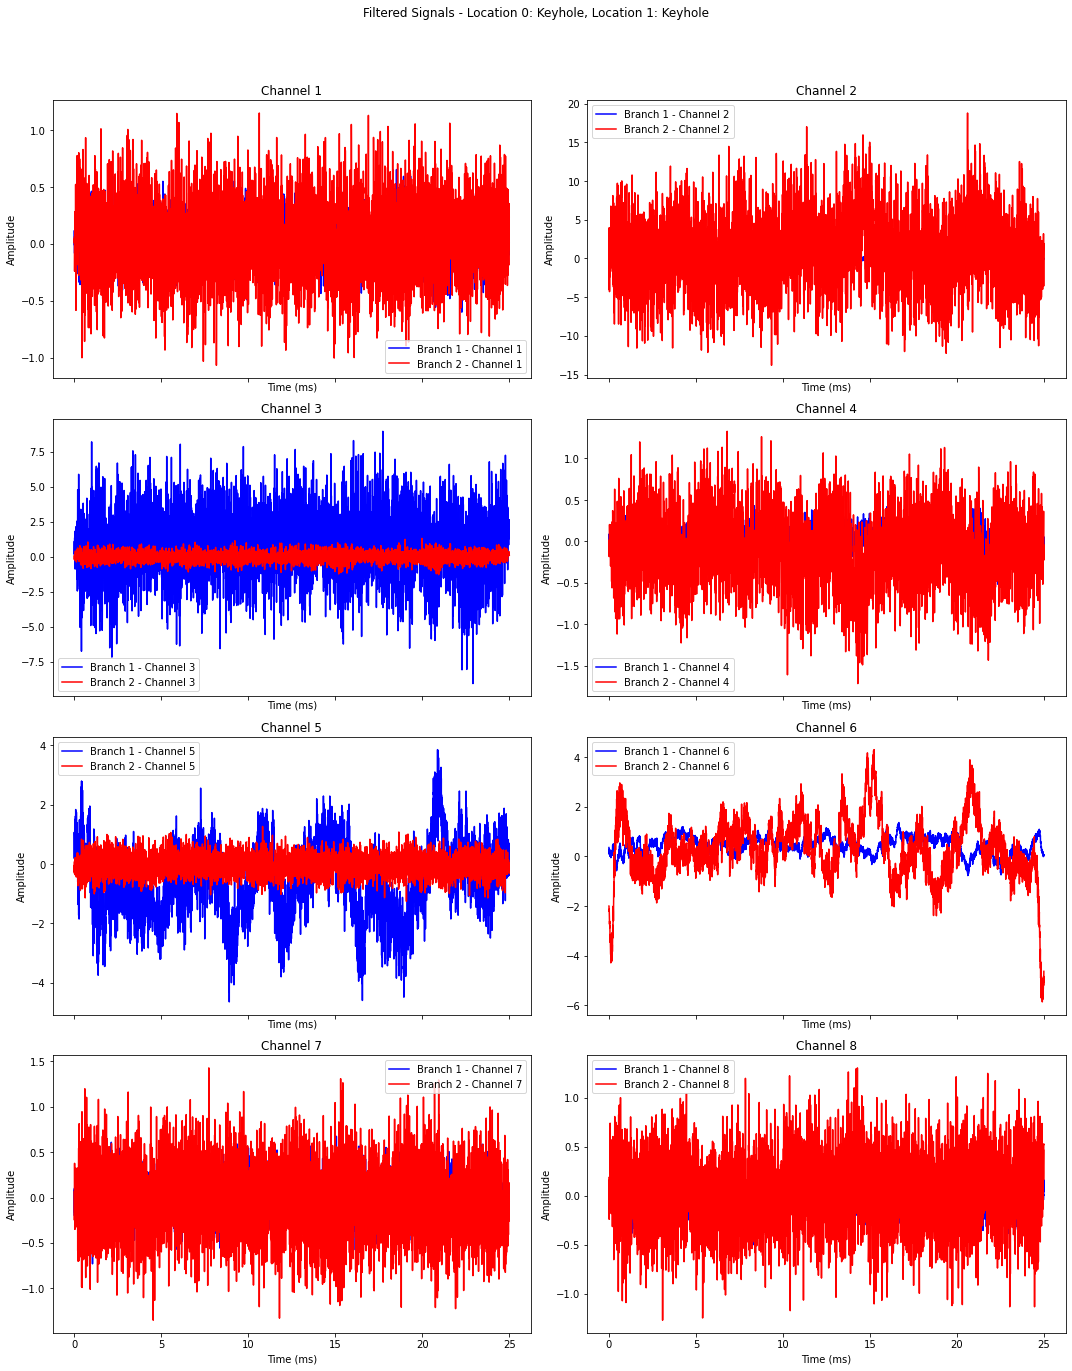

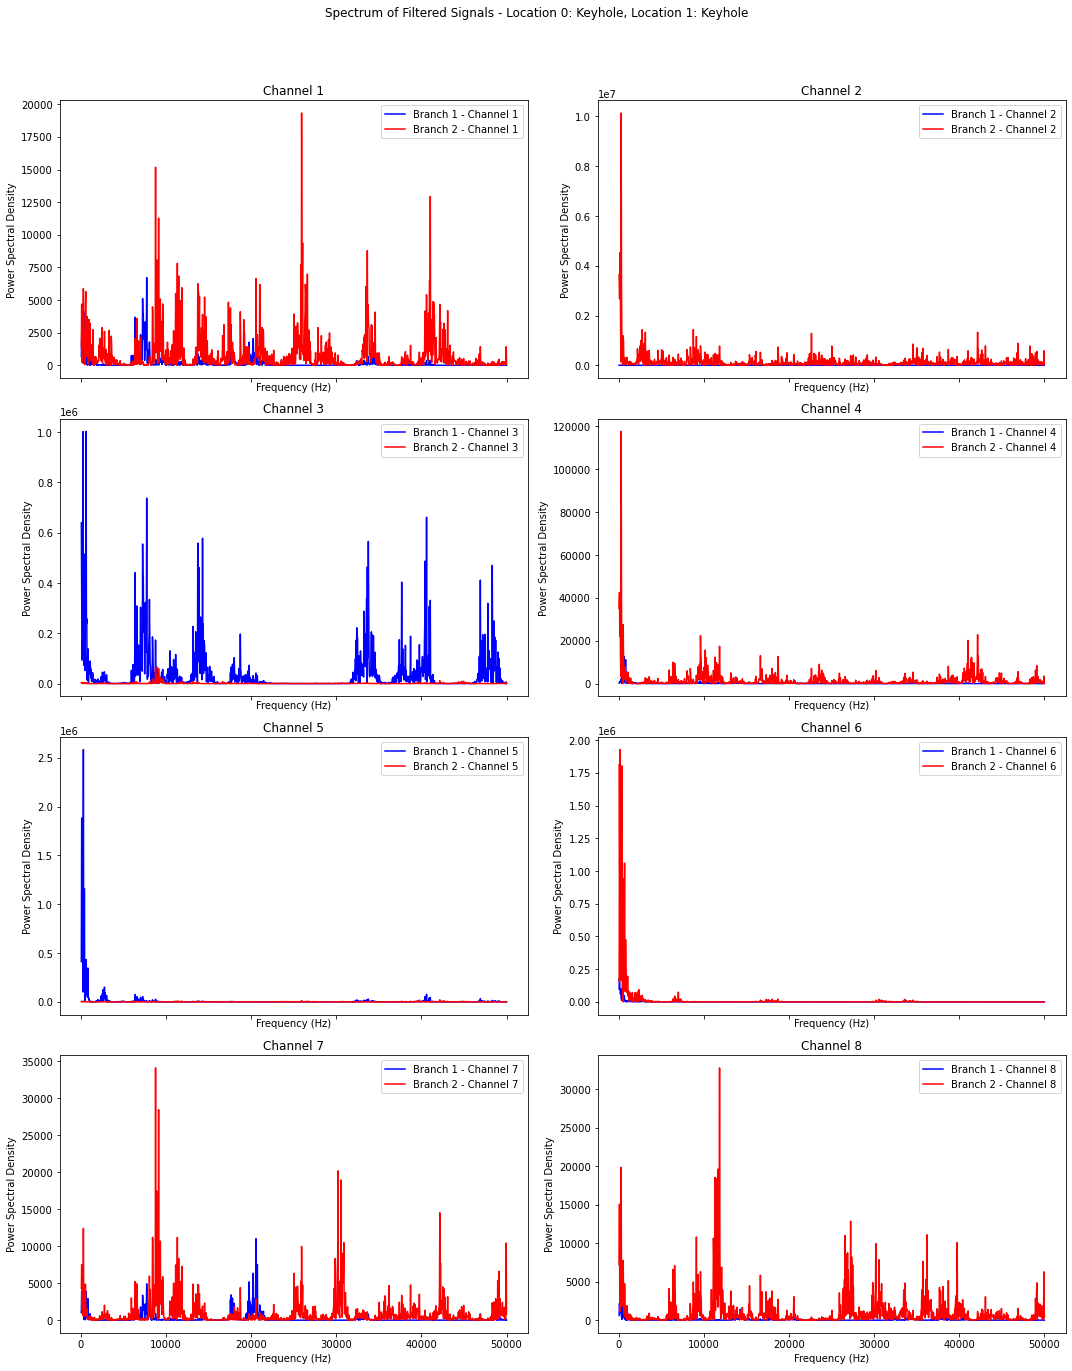

----------------------------------------


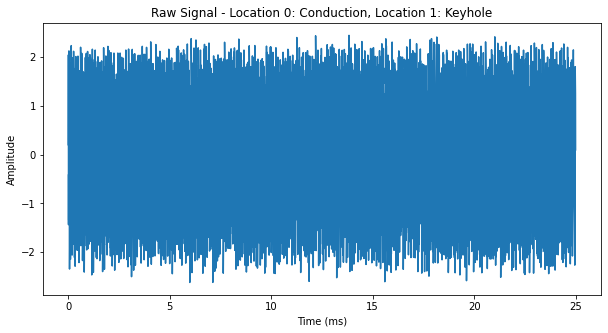

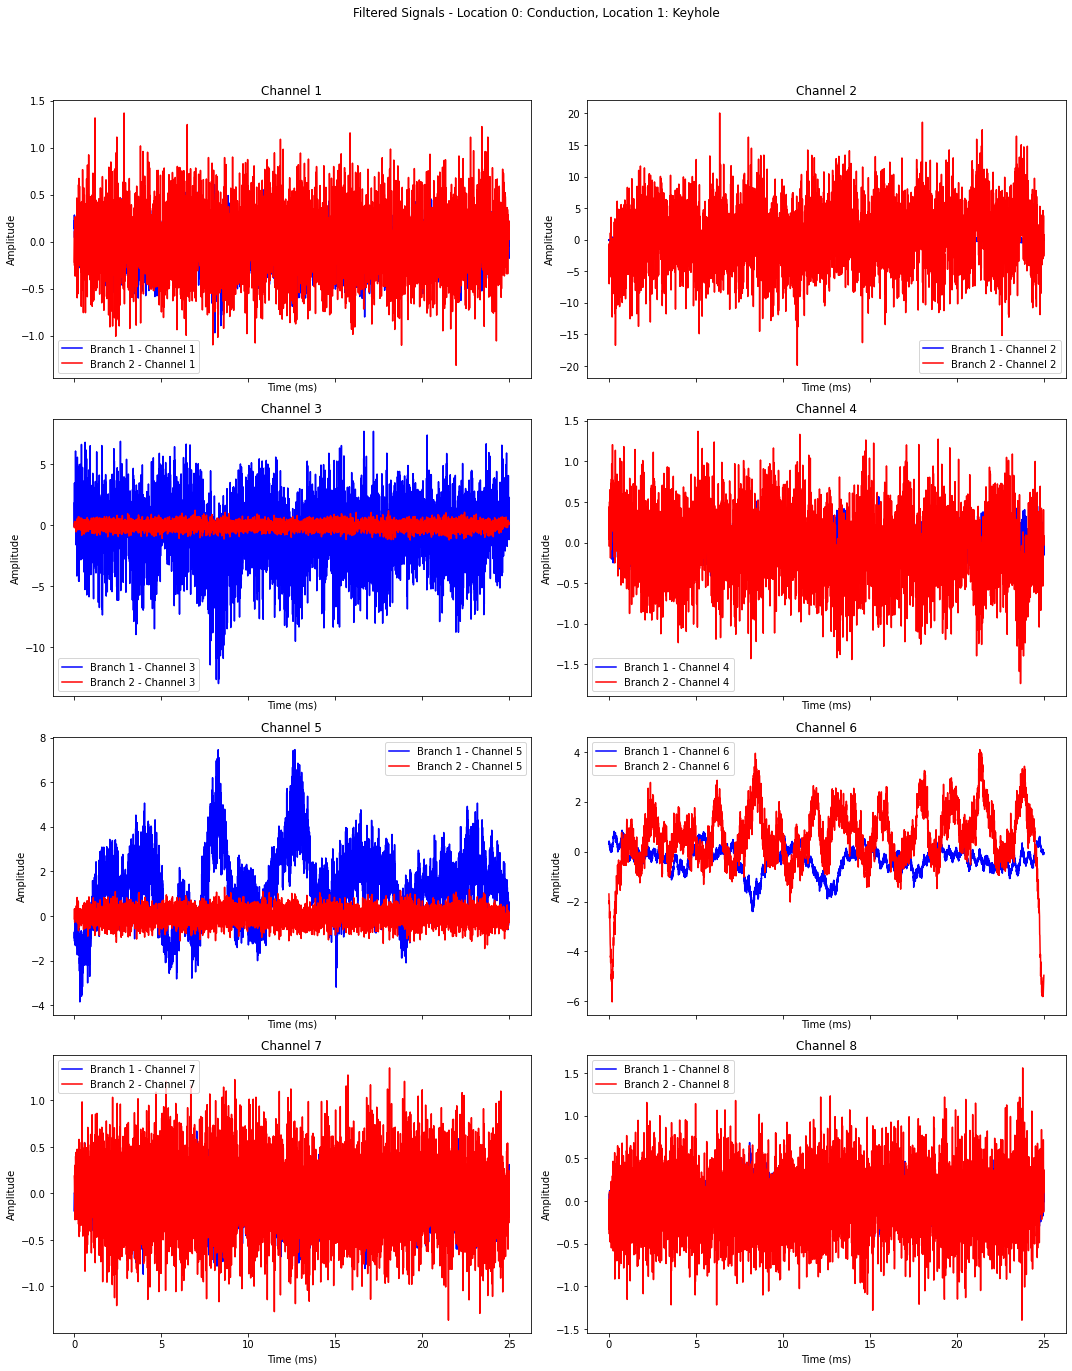

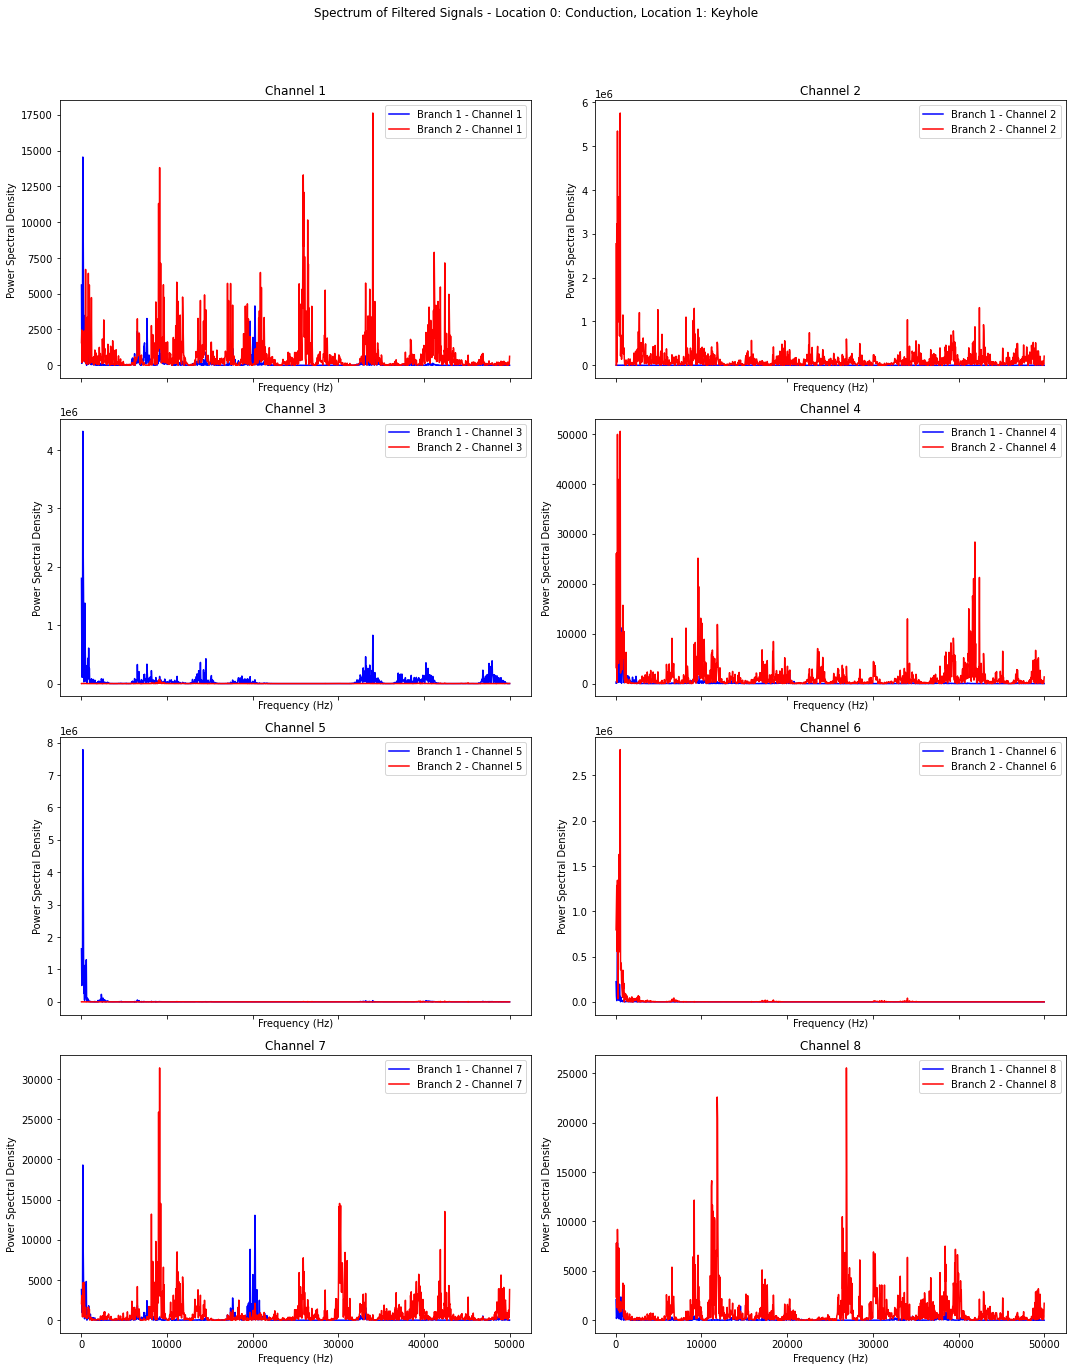

----------------------------------------


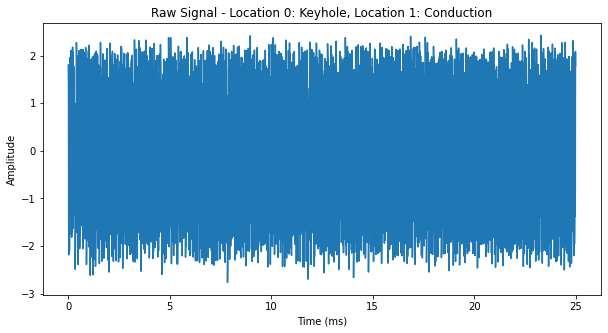

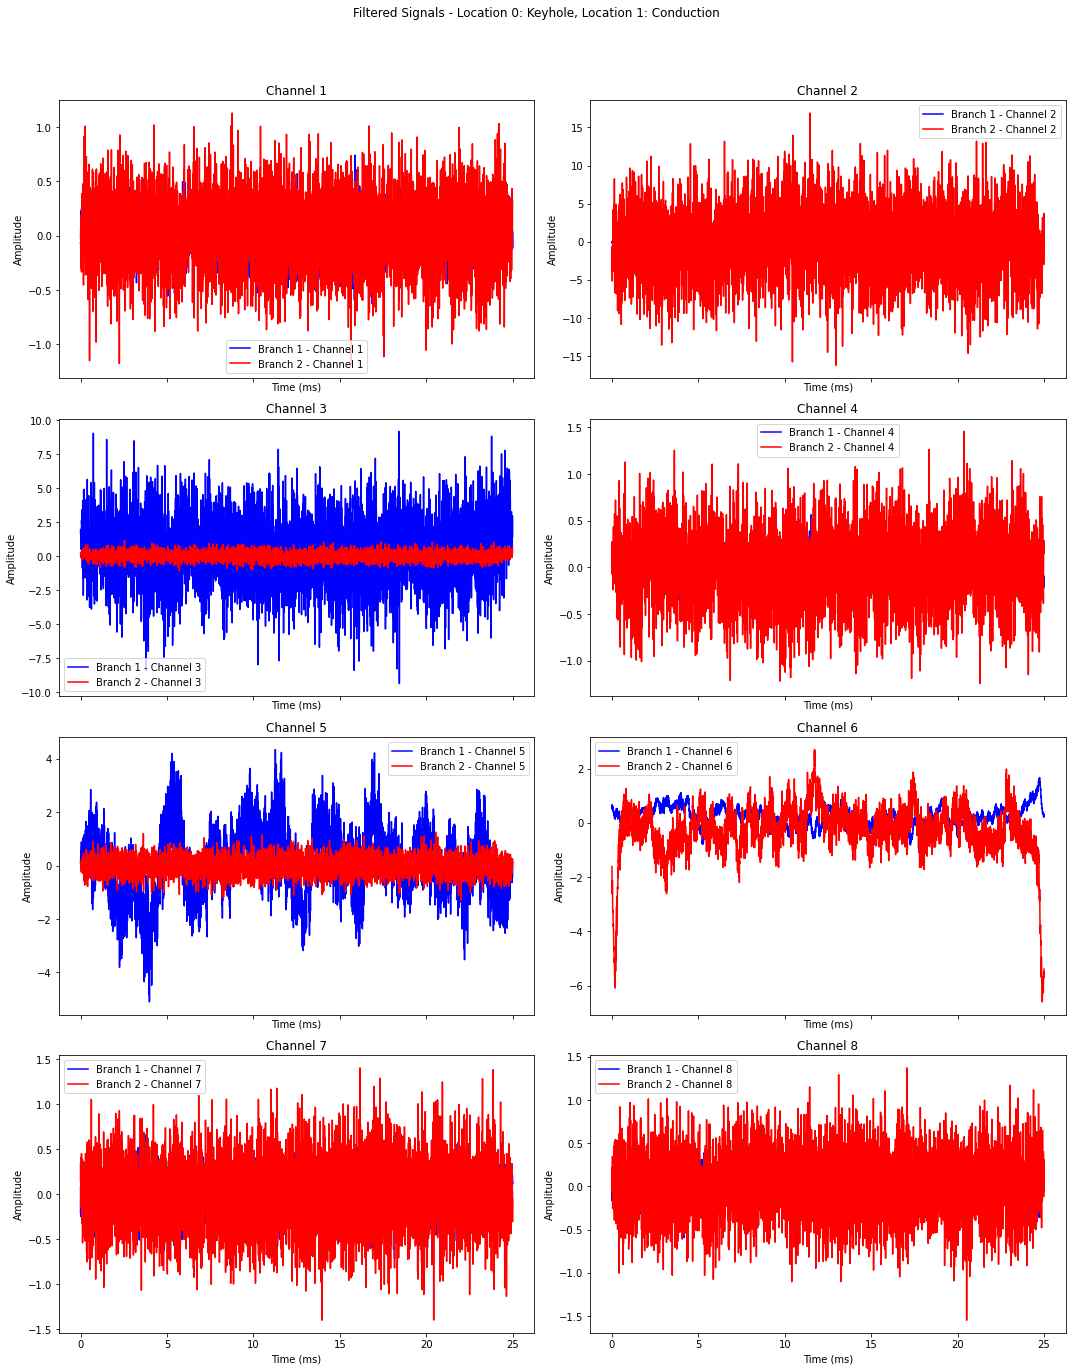

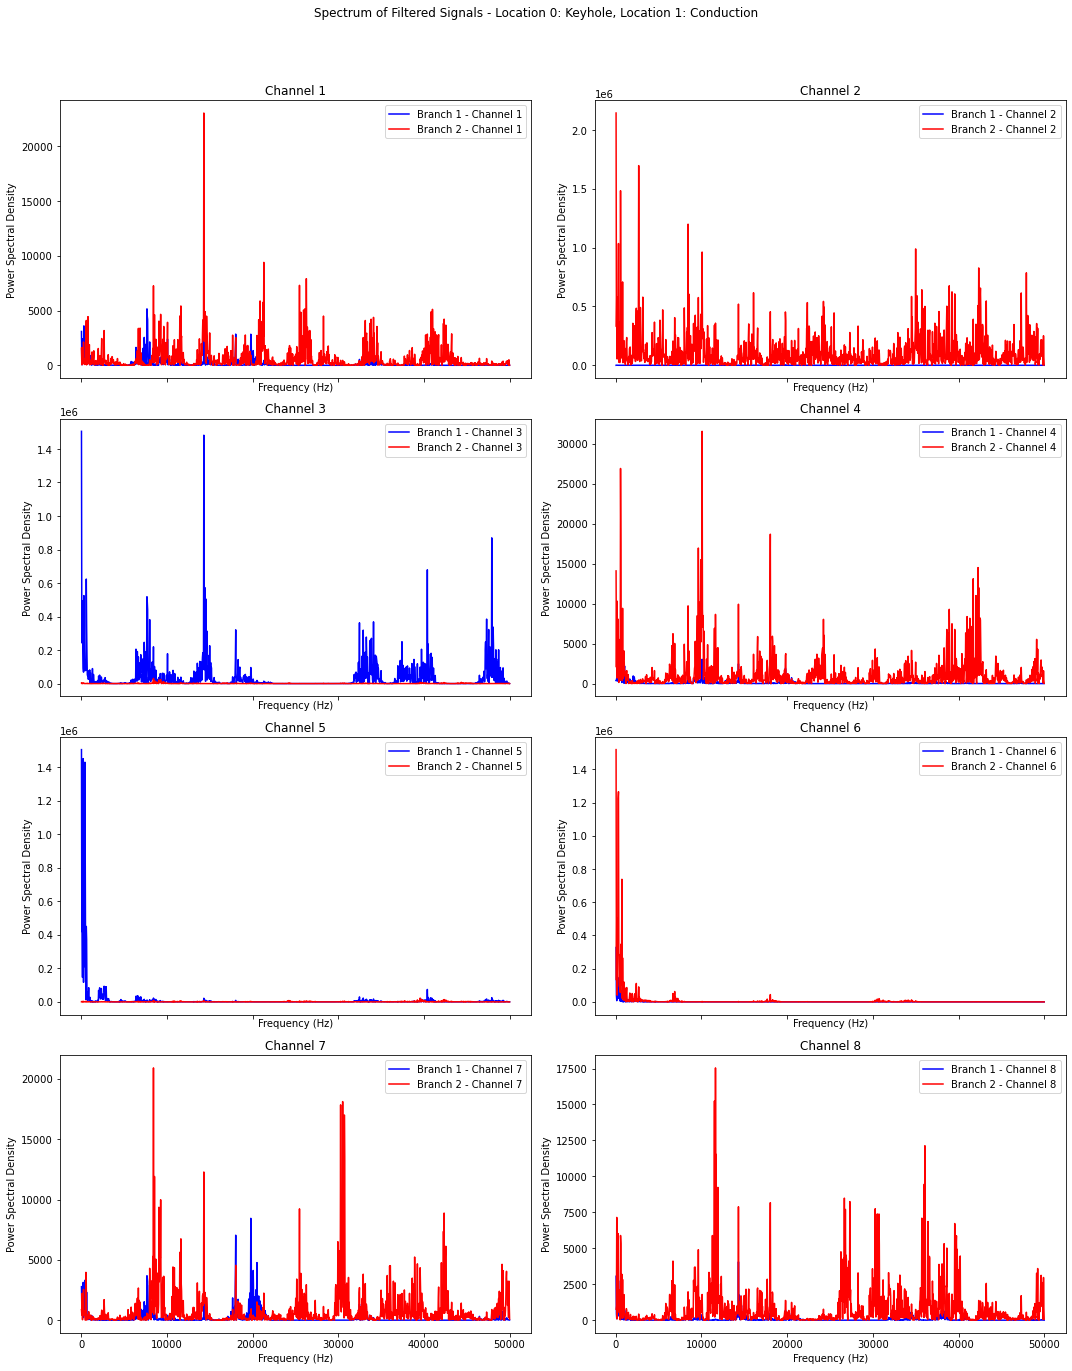

----------------------------------------


In [6]:
# Evaluate model and plot signals
all_targets1, all_targets2 = [], []
all_x_branch1, all_x_branch2 = [], []
selected_signals = {0: None, 1: None, 2: None, 3: None}  # Dictionary to store selected signals

with torch.no_grad():
    for data, (target1, target2), _ in test_loader_sim:
        data = data.to(device)
        target1, target2 = target1.to(device).float(), target2.to(device).float()

        ou1, out2, x_branch1, x_branch2 = model_sim(data)
        
        for i in range(data.size(0)):
            if target1[i] == 0 and target2[i] == 0 and selected_signals[0] is None:
                selected_signals[0] = (data[i], x_branch1[i], x_branch2[i], target1[i], target2[i])
            elif target1[i] == 1 and target2[i] == 1 and selected_signals[1] is None:
                selected_signals[1] = (data[i], x_branch1[i], x_branch2[i], target1[i], target2[i])
            elif target1[i] == 0 and target2[i] == 1 and selected_signals[2] is None:
                selected_signals[2] = (data[i], x_branch1[i], x_branch2[i], target1[i], target2[i])
            elif target1[i] == 1 and target2[i] == 0 and selected_signals[3] is None:
                selected_signals[3] = (data[i], x_branch1[i], x_branch2[i], target1[i], target2[i])
        
        if all(selected_signals.values()):
            break

# Define sampling rate
sampling_rate = 200000  # 200kS/s

# Plot the selected raw signals
for key, (raw_signal, x_branch1_signal, x_branch2_signal, target1, target2) in selected_signals.items():
    target_desc = f"Location 0: {'Conduction' if target1 == 0 else 'Keyhole'}, Location 1: {'Conduction' if target2 == 0 else 'Keyhole'}"
    plot_raw_signal(raw_signal, sampling_rate, f"Raw Signal - {target_desc}")

    # Plot the combined filtered signals for each branch
    plot_combined_channels(x_branch1_signal.cpu(), x_branch2_signal.cpu(), sampling_rate, f"Filtered Signals - {target_desc}")

    # Plot the combined spectra for each branch
    max_frequency = 50000  # Set the maximum frequency to limit the plot
    plot_combined_spectrum(x_branch1_signal.cpu(), x_branch2_signal.cpu(), sampling_rate, f"Spectrum of Filtered Signals - {target_desc}", max_freq=max_frequency)
    print('----'*10)

In [10]:
# Define helper functions for evaluation and plotting
def plot_combined_median_signals(signal_target0, signal_target1, sampling_rate, title):
    median_signal_target0 = torch.median(signal_target0, dim=0)[0].cpu().numpy().flatten()
    median_signal_target1 = torch.median(signal_target1, dim=0)[0].cpu().numpy().flatten()
    time = np.arange(len(median_signal_target0)) / sampling_rate * 1000  # Convert to ms
    plt.figure(figsize=(10, 5))
    plt.plot(time, median_signal_target0, label='Conduction', color='b')
    plt.plot(time, median_signal_target1, label='Keyhole', color='r')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Median Amplitude')
    plt.legend()
    plt.show()

def plot_combined_median_channels(x_branch1_target0, x_branch1_target1, sampling_rate, title):
    median_signals_target0 = torch.median(x_branch1_target0, dim=0)[0].cpu().numpy()
    median_signals_target1 = torch.median(x_branch1_target1, dim=0)[0].cpu().numpy()
    time = np.arange(median_signals_target0.shape[1]) / sampling_rate * 1000  # Convert to ms
    fig, axes = plt.subplots(4, 2, figsize=(15, 20), sharex=True)
    axes = axes.flatten()
    for i in range(8):
        axes[i].plot(time, median_signals_target0[i], label='Conduction', color='b')
        axes[i].plot(time, median_signals_target1[i], label='Keyhole', color='r')
        axes[i].set_title(f'Channel {i+1}')
        axes[i].set_xlabel('Time (ms)')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_combined_median_spectrum(x_branch1_target0, x_branch1_target1, sampling_rate, title, max_freq=None):
    fig, axes = plt.subplots(4, 2, figsize=(15, 20), sharex=True)
    axes = axes.flatten()
    for i in range(8):
        median_signal_target0 = torch.median(x_branch1_target0[:, i, :], dim=0)[0]
        median_signal_target1 = torch.median(x_branch1_target1[:, i, :], dim=0)[0]
        
        signal_target0 = median_signal_target0.numpy().flatten()
        signal_target1 = median_signal_target1.numpy().flatten()
        
        n = len(signal_target0)
        fhat_target0 = np.fft.fft(signal_target0, n)
        fhat_target1 = np.fft.fft(signal_target1, n)
        
        psd_target0 = np.abs(fhat_target0) ** 2
        psd_target1 = np.abs(fhat_target1) ** 2
        
        freq = np.fft.fftfreq(n, 1 / sampling_rate)
        
        l = np.arange(1, np.floor(n / 2), dtype=int)  # Only plot the positive frequencies

        if max_freq is not None:
            l = l[freq[l] <= max_freq]  # Limit the frequencies to max_freq

        axes[i].plot(freq[l], psd_target0[l], label='Conduction', color='b')
        axes[i].plot(freq[l], psd_target1[l], label='Keyhole', color='r')
        axes[i].set_title(f'Channel {i+1}')
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Power Spectral Density')
        axes[i].legend()
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Here, we plot the median signals for both the raw and filtered data, differentiating between the conduction and keyhole modes. This analysis helps us understand the typical signal characteristics in each mode and provides a clearer comparison between them. We evaluate a set of 1000 signals to ensure robustness and statistical significance.

Here we focus on the first branch.

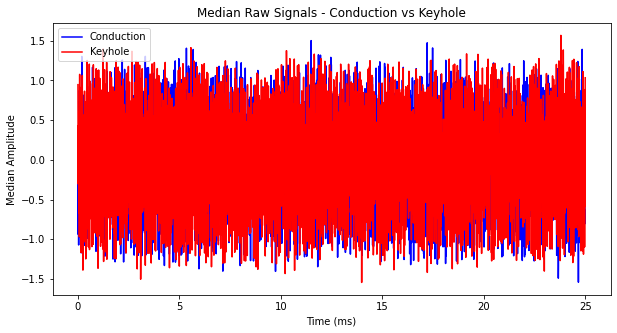

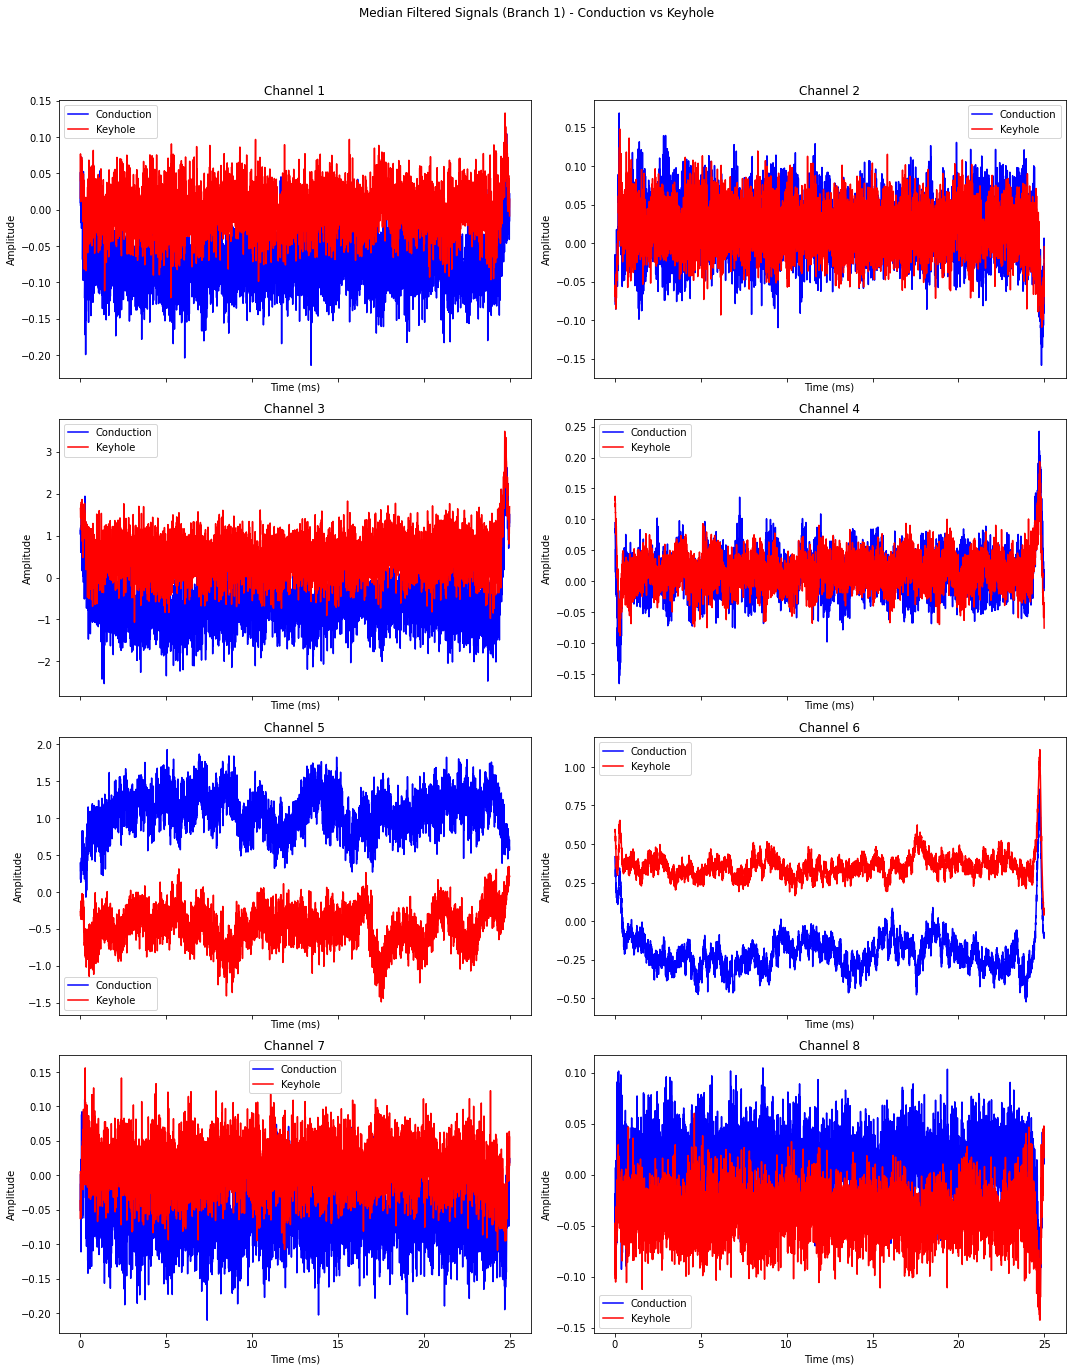

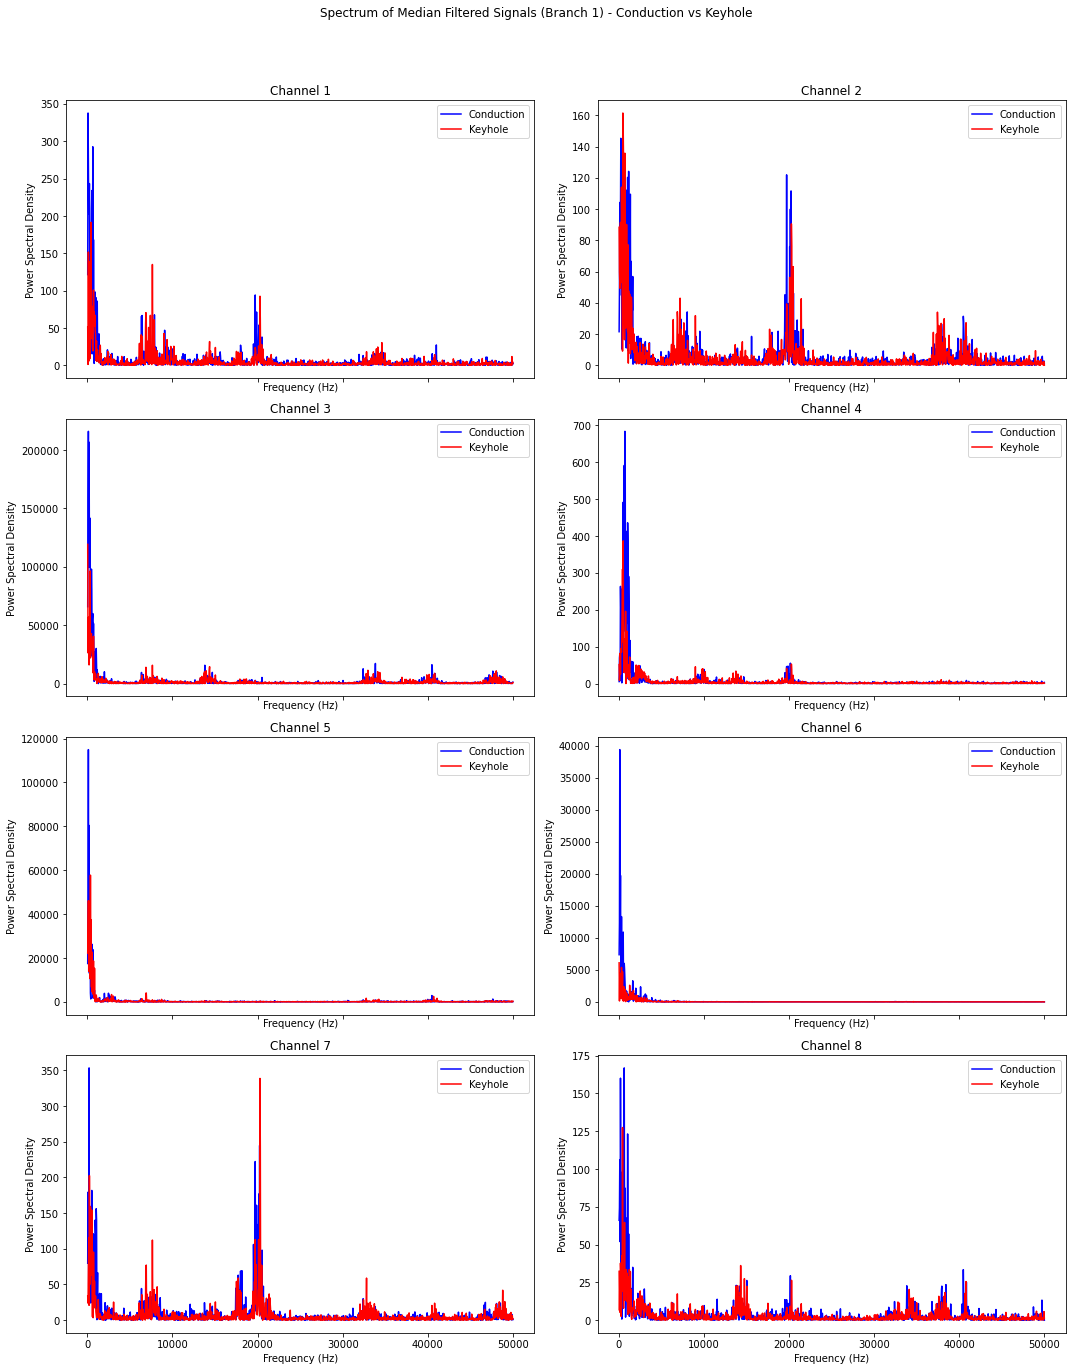

In [11]:
# Number of signals to plot
N = 1000

# Evaluate model and gather signals
all_targets1, all_targets2 = [], []
all_x_branch1 = []
all_raw_data = []

with torch.no_grad():
    for data, (target1, target2), _ in test_loader_sim:
        data = data.to(device)
        target1, target2 = target1.to(device).float(), target2.to(device).float()

        ou1, out2, x_branch1, x_branch2 = model_sim(data)
        
        all_x_branch1.append(x_branch1.cpu())
        all_targets1.append(target1.cpu())
        all_targets2.append(target2.cpu())
        all_raw_data.append(data.cpu())
        
        if len(all_targets1) * data.size(0) >= N:
            break

# Concatenate results for processing
all_x_branch1 = torch.cat(all_x_branch1)[:N]
all_raw_data = torch.cat(all_raw_data)[:N]
all_targets1 = torch.cat(all_targets1)[:N]
all_targets2 = torch.cat(all_targets2)[:N]

# Separate raw signals based on target value
raw_data_target0 = all_raw_data[all_targets1 == 0]
raw_data_target1 = all_raw_data[all_targets1 == 1]

# Separate filtered signals based on target value
x_branch1_target0 = all_x_branch1[all_targets1 == 0]
x_branch1_target1 = all_x_branch1[all_targets1 == 1]

# Define sampling rate
sampling_rate = 200000  # 200kS/s

# Plot combined median raw signals
plot_combined_median_signals(raw_data_target0, raw_data_target1, sampling_rate, "Median Raw Signals - Conduction vs Keyhole")

# Plot combined median of filtered signals based on target
plot_combined_median_channels(x_branch1_target0, x_branch1_target1, sampling_rate, "Median Filtered Signals (Branch 1) - Conduction vs Keyhole")

# Plot combined median spectrum of the filtered signals with a specified max frequency
max_frequency = 50000  # Set the maximum frequency to limit the plot

plot_combined_median_spectrum(x_branch1_target0, x_branch1_target1, sampling_rate, "Spectrum of Median Filtered Signals (Branch 1) - Conduction vs Keyhole", max_freq=max_frequency)

Here we focus on the second branch.

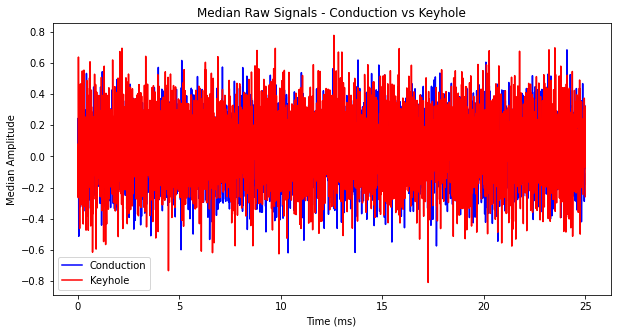

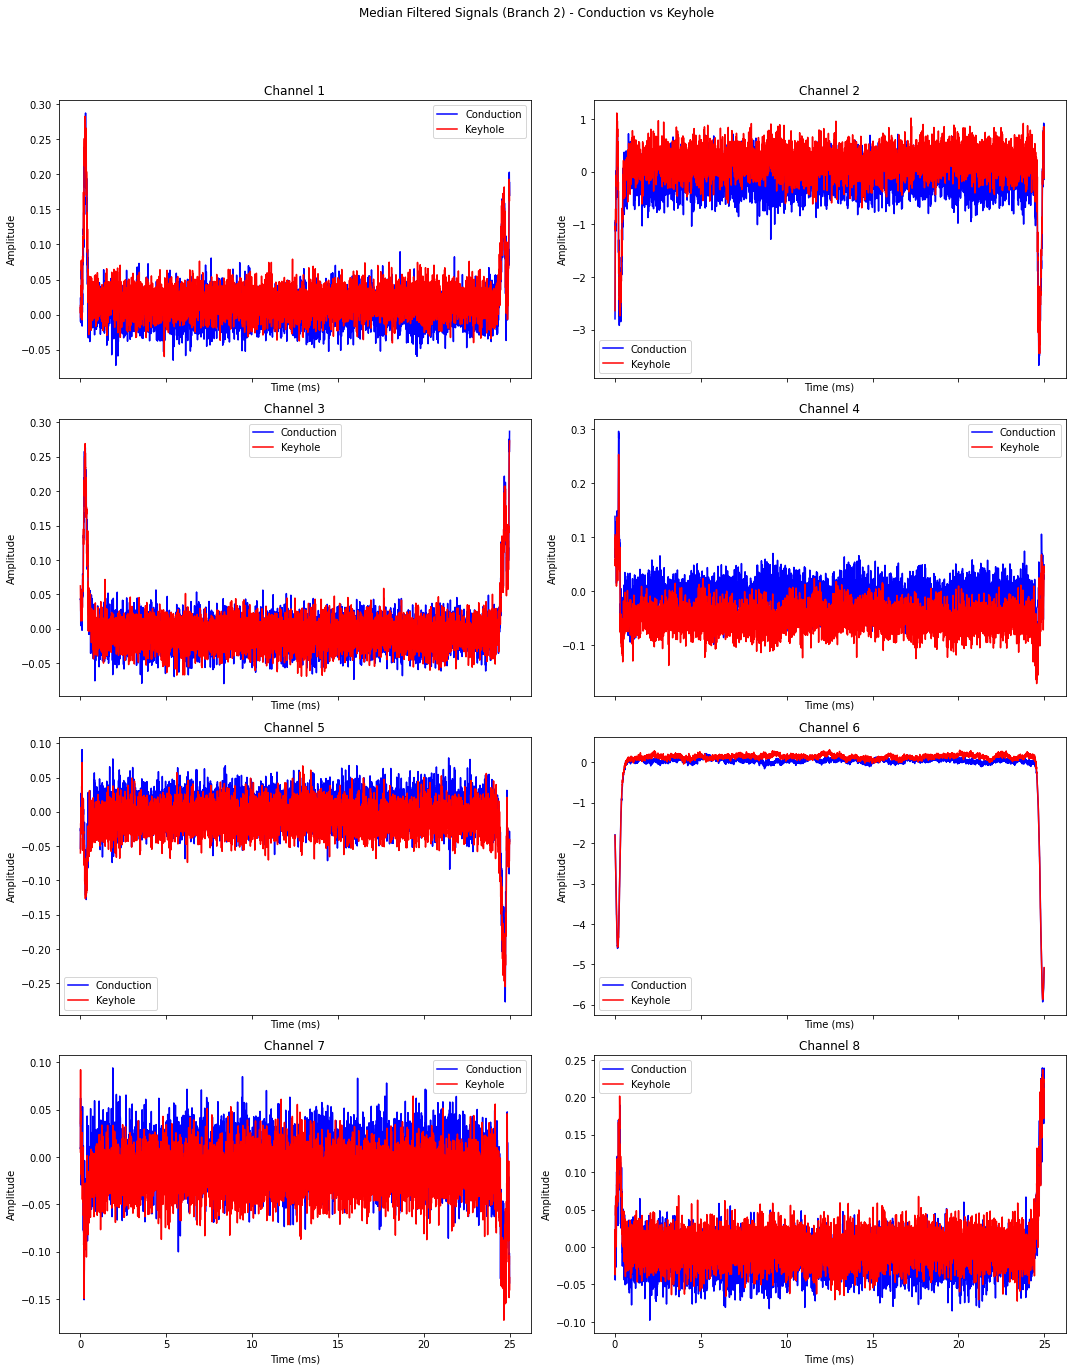

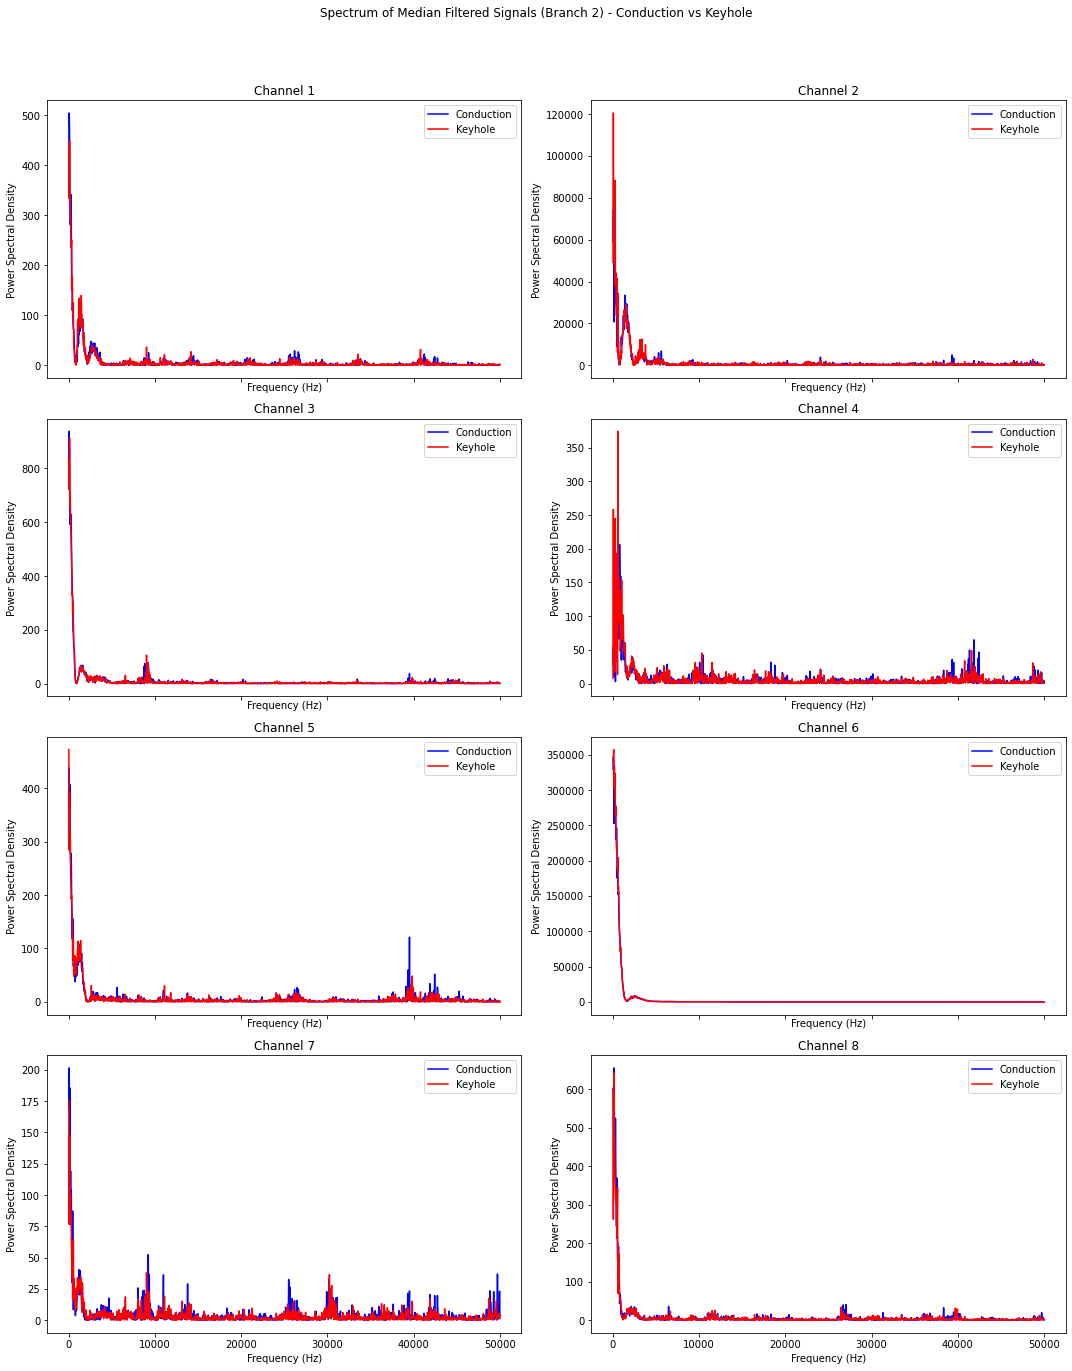

In [13]:
# Number of signals to plot
N = 1000

# Evaluate model and gather signals
all_targets1, all_targets2 = [], []
all_x_branch2 = []
all_raw_data = []

with torch.no_grad():
    for data, (target1, target2), _ in test_loader_sim:
        data = data.to(device)
        target1, target2 = target1.to(device).float(), target2.to(device).float()

        ou1, out2, x_branch1, x_branch2 = model_sim(data)
        
        all_x_branch2.append(x_branch2.cpu())
        all_targets1.append(target1.cpu())
        all_targets2.append(target2.cpu())
        all_raw_data.append(data.cpu())
        
        if len(all_targets1) * data.size(0) >= N:
            break

# Concatenate results for processing
all_x_branch2 = torch.cat(all_x_branch2)[:N]
all_raw_data = torch.cat(all_raw_data)[:N]
all_targets1 = torch.cat(all_targets1)[:N]
all_targets2 = torch.cat(all_targets2)[:N]

# Separate raw signals based on target value
raw_data_target0 = all_raw_data[all_targets2 == 0]
raw_data_target1 = all_raw_data[all_targets2 == 1]

# Separate filtered signals based on target value
x_branch2_target0 = all_x_branch2[all_targets1 == 0]
x_branch2_target1 = all_x_branch2[all_targets1 == 1]

# Define sampling rate
sampling_rate = 200000  # 200kS/s

# Plot combined median raw signals
plot_combined_median_signals(raw_data_target0, raw_data_target1, sampling_rate, "Median Raw Signals - Conduction vs Keyhole")

# Plot combined median of filtered signals based on target
plot_combined_median_channels(x_branch2_target0, x_branch2_target1, sampling_rate, "Median Filtered Signals (Branch 2) - Conduction vs Keyhole")

# Plot combined median spectrum of the filtered signals with a specified max frequency
max_frequency = 50000  # Set the maximum frequency to limit the plot

plot_combined_median_spectrum(x_branch2_target0, x_branch2_target1, sampling_rate, "Spectrum of Median Filtered Signals (Branch 2) - Conduction vs Keyhole", max_freq=max_frequency)